# What Does ESCO Consider Essential for a Data Scientist?

**A reproducible exploration of 63 essential concepts in ESCO v1.2.1**

**Author:** Adel Sahli

This notebook explores the knowledge, skills and competences that ESCO links
to the occupation **data scientist** as essential. It creates an interactive
treemap, a searchable table and a LinkedIn-ready infographic.

## Important interpretation

ESCO is a European classification of occupations and skills. In the ESCO
handbook, an **essential** concept is usually relevant to an occupation across
work contexts, employers and countries.

This does **not** mean that a person must master all 63 concepts to be a “real”
data scientist. Real jobs differ by industry, seniority and employer.

**Research question:** What knowledge, skills and competences does ESCO v1.2.1
classify as essential for a data scientist?

## 1. Setup

The repository includes two small adapted subsets of ESCO v1.2.1. They
contain only the 63 essential data scientist relations and their matching
descriptions.

**This publication uses the ESCO classification of the European Commission.**

The complete source classification is available from the
[official ESCO download page](https://esco.ec.europa.eu/en/use-esco/download).

In [1]:
# Import the libraries used in this notebook

from pathlib import Path
import textwrap

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from itables import show

In [2]:
# Define the input and output file locations

DATA_FOLDER = Path("data")
OUTPUT_FOLDER = Path("outputs")

RELATIONS_FILE = (
    DATA_FOLDER
    / "esco_v1_2_1_data_scientist_essential_relations.csv"
)
SKILLS_FILE = (
    DATA_FOLDER
    / "esco_v1_2_1_data_scientist_skill_descriptions.csv"
)

OUTPUT_FOLDER.mkdir(exist_ok=True)

In [3]:
# Check that the required ESCO files are available

required_files = [RELATIONS_FILE, SKILLS_FILE]
missing_files = [str(file) for file in required_files if not file.exists()]

if missing_files:
    raise FileNotFoundError(
        "Missing file(s): " + ", ".join(missing_files) +
        ". Download the complete repository and keep its data folder."
    )

print("The required ESCO files are available.")

The required ESCO files are available.


## 2. Load and prepare the ESCO data

We need two tables:

- The occupation–skill relations table tells us which skills are connected to
  the data scientist occupation.
- The skills table provides the official description of each concept.

The tables are joined with `skill_uri`, which is a stable ESCO identifier.

In [4]:
# Load the occupation-skill relations and skill descriptions

relations = pd.read_csv(RELATIONS_FILE)
skills = pd.read_csv(SKILLS_FILE)

print("Relations shape:", relations.shape)
print("Skills shape:", skills.shape)

Relations shape: (63, 5)
Skills shape: (63, 2)


In [5]:
# Rename only the columns needed for this analysis

relations = relations.rename(columns={
    "occupationLabel": "occupation_name",
    "relationType": "relation_type",
    "skillType": "skill_type",
    "skillUri": "skill_uri",
    "skillLabel": "skill_name"
})

skills = skills.rename(columns={
    "conceptUri": "skill_uri",
    "description": "skill_description"
})

In [6]:
# Select the essential concepts linked to the data scientist occupation

essential_relations = relations[
    (relations["occupation_name"].str.lower() == "data scientist") &
    (relations["relation_type"] == "essential")
][["skill_uri", "skill_name", "skill_type"]].copy()

print("Essential relations found:", len(essential_relations))

Essential relations found: 63


In [7]:
# Join every essential concept to its official ESCO description

skill_descriptions = skills[
    ["skill_uri", "skill_description"]
].drop_duplicates(subset="skill_uri")

essential_skills = essential_relations.merge(
    skill_descriptions,
    on="skill_uri",
    how="left"
)

essential_skills = essential_skills.sort_values(
    ["skill_type", "skill_name"]
).reset_index(drop=True)

## 3. Validate the result

Before visualizing the data, we check the number of unique concepts,
duplicate identifiers and missing descriptions.

In [8]:
# Check the quality of the final essential-skills table

quality_check = pd.DataFrame({
    "check": [
        "Number of rows",
        "Unique skill URIs",
        "Duplicate skill URIs",
        "Missing descriptions"
    ],
    "result": [
        len(essential_skills),
        essential_skills["skill_uri"].nunique(),
        essential_skills["skill_uri"].duplicated().sum(),
        essential_skills["skill_description"].isna().sum()
    ]
})

display(quality_check)

,check,result
0,Number of rows,63
1,Unique skill URIs,63
2,Duplicate skill URIs,0
3,Missing descriptions,0


In [9]:
# Confirm whether this ESCO version produces the expected 63 concepts

total_concepts = len(essential_skills)

if total_concepts == 63:
    print("Verified: ESCO v1.2.1 lists 63 essential concepts for data scientist.")
else:
    print(
        f"This dataset produced {total_concepts} concepts. "
        "Check that you downloaded ESCO v1.2.1."
    )

Verified: ESCO v1.2.1 lists 63 essential concepts for data scientist.


## 4. How are the 63 concepts divided?

ESCO records two skill types:

- **skill/competence:** the ability to apply knowledge and use methods to
  complete tasks or solve problems;
- **knowledge:** facts, principles, theories and practices related to a field
  of work or study.

ESCO does not separate skills and competences into two different types.

In [10]:
# Count the essential concepts in each ESCO skill type

type_summary = (
    essential_skills["skill_type"]
    .value_counts()
    .rename_axis("skill_type")
    .reset_index(name="number_of_concepts")
)

display(type_summary)

,skill_type,number_of_concepts
0,skill/competence,45
1,knowledge,18


In [11]:
# Create a bar chart comparing the two ESCO skill types

type_chart = px.bar(
    type_summary,
    x="skill_type",
    y="number_of_concepts",
    color="skill_type",
    text="number_of_concepts",
    title="Essential Data Scientist Concepts by ESCO Skill Type"
)

type_chart.update_layout(
    xaxis_title="ESCO skill type",
    yaxis_title="Number of essential concepts",
    showlegend=False
)

type_chart.show()

## 5. Interactive treemap

Every small block represents one essential concept. All blocks have equal
weight because ESCO does not provide an importance score. Hover over a block
to read its official description.

In [12]:
# Prepare readable descriptions for the treemap hover information

essential_skills["description_for_chart"] = essential_skills[
    "skill_description"
].fillna("No description available").apply(
    lambda text: "<br>".join(textwrap.wrap(str(text), width=70))
)

essential_skills["occupation"] = "Data scientist"
essential_skills["equal_weight"] = 1

In [13]:
# Create and save the interactive essential-skills treemap

treemap = px.treemap(
    essential_skills,
    path=["occupation", "skill_type", "skill_name"],
    values="equal_weight",
    color="skill_type",
    custom_data=["description_for_chart"],
    title="63 Essential Concepts in the ESCO Data Scientist Profile"
)

treemap.update_traces(
    textinfo="label",
    hovertemplate=(
        "<b>%{label}</b><br><br>"
        "<b>Description:</b><br>%{customdata[0]}"
        "<extra></extra>"
    )
)

treemap.update_layout(margin=dict(t=60, l=10, r=10, b=10))
treemap.show()

treemap.write_html(
    OUTPUT_FOLDER / "data_scientist_essential_skills_treemap.html"
)

## 6. Searchable table

Use the search box to find a topic such as `statistics`, `ethics` or
`database`. Click a column name to sort the table.

In [14]:
# Display all concepts and descriptions in a searchable interactive table

interactive_table = essential_skills[
    ["skill_name", "skill_type", "skill_description"]
].rename(columns={
    "skill_name": "Skill or knowledge concept",
    "skill_type": "ESCO skill type",
    "skill_description": "Official ESCO description"
})

show(interactive_table)

In [15]:
# Export the clean essential-skills data for reuse

essential_skills[
    ["skill_uri", "skill_name", "skill_type", "skill_description"]
].to_csv(
    OUTPUT_FOLDER / "data_scientist_essential_skills.csv",
    index=False
)

print("The clean CSV was saved in the outputs folder.")

The clean CSV was saved in the outputs folder.


## 7. Create a LinkedIn infographic

The following cell creates a vertical 1080 × 1350 image. It uses the result
calculated above, so the total and category counts are not typed manually.

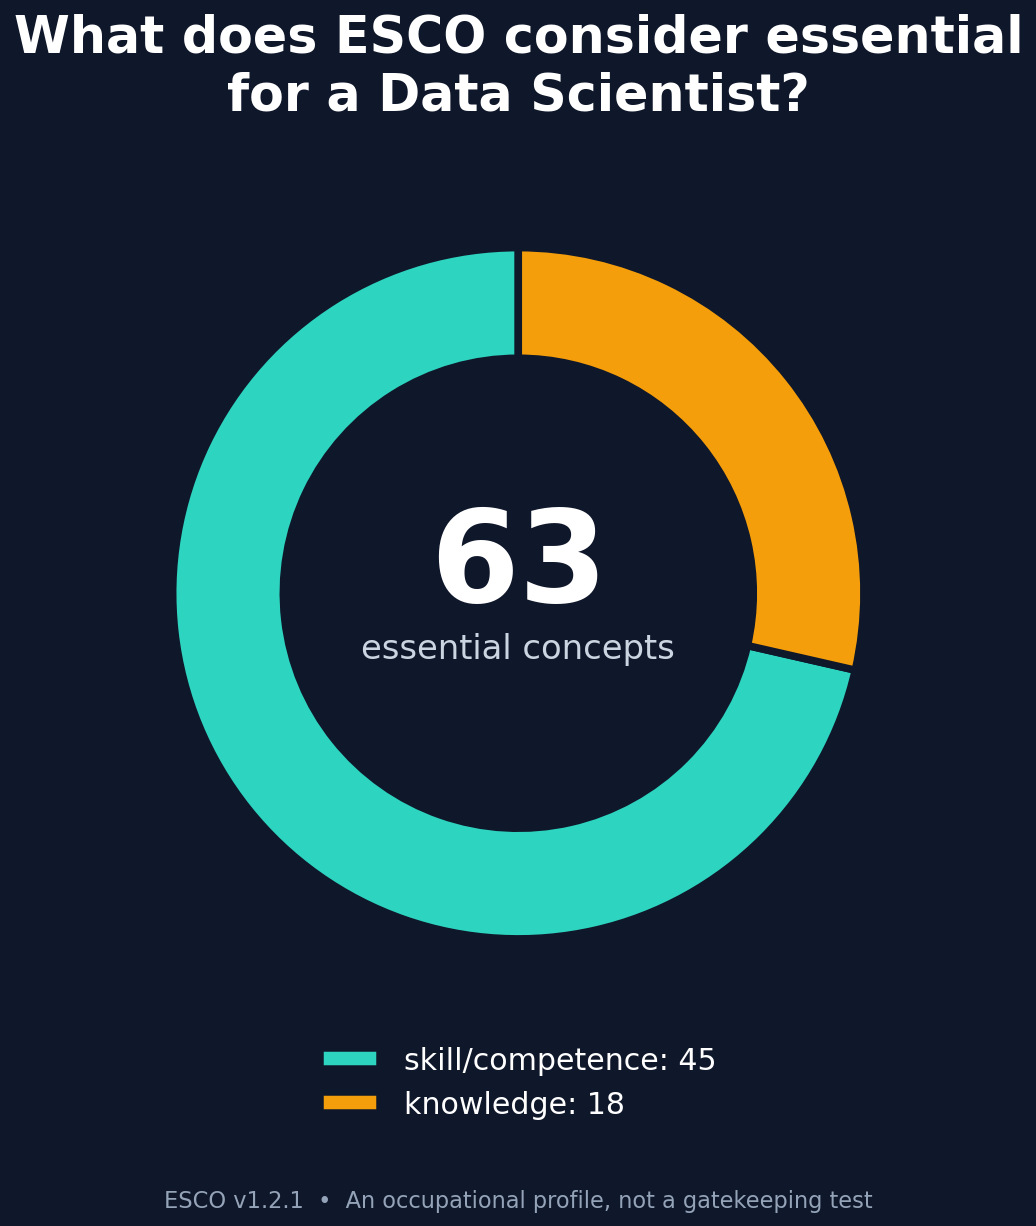

In [16]:
# Create a LinkedIn-ready infographic from the calculated results

card_counts = type_summary.set_index("skill_type")[
    "number_of_concepts"
]

chart_values = card_counts.values
chart_labels = [
    f"{skill_type}: {count}"
    for skill_type, count in card_counts.items()
]

figure, axis = plt.subplots(figsize=(8, 10), dpi=135)
figure.patch.set_facecolor("#0F172A")
axis.set_facecolor("#0F172A")

axis.pie(
    chart_values,
    startangle=90,
    colors=["#2DD4BF", "#F59E0B"],
    wedgeprops={"width": 0.32, "edgecolor": "#0F172A", "linewidth": 4}
)

axis.text(
    0, 0.08, str(total_concepts),
    ha="center", va="center",
    fontsize=68, fontweight="bold", color="white"
)
axis.text(
    0, -0.16, "essential concepts",
    ha="center", va="center",
    fontsize=18, color="#CBD5E1"
)

figure.suptitle(
    "What does ESCO consider essential\nfor a Data Scientist?",
    fontsize=27,
    fontweight="bold",
    color="white",
    y=0.93
)

axis.legend(
    chart_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.14),
    ncol=1,
    frameon=False,
    fontsize=16,
    labelcolor="white"
)

figure.subplots_adjust(
    top=0.82,
    bottom=0.18,
    left=0.05,
    right=0.95
)

figure.text(
    0.5, 0.045,
    "ESCO v1.2.1  •  An occupational profile, not a gatekeeping test",
    ha="center",
    fontsize=12,
    color="#94A3B8"
)

axis.set_aspect("equal")
plt.savefig(
    OUTPUT_FOLDER / "linkedin_essential_skills_card.png",
    dpi=135,
    facecolor=figure.get_facecolor()
)
plt.show()

## 8. Ethics and responsible interpretation

This analysis uses public occupational data and does not contain personal
data. However, the result could become harmful if it is used incorrectly in
recruitment or career matching.

### Main ethical risks

1. **Gatekeeping:** A person should not be rejected simply because they do not
   list all 63 concepts. Skills can be learned, expressed differently or
   demonstrated through experience.
2. **Context and classification bias:** ESCO describes a general European
   occupation. It may not represent every industry, employer, country or
   non-traditional career path equally.
3. **False measurement:** The presence of a skill name does not measure a
   person's level, experience or work quality.
4. **Automation risk:** A taxonomy can support human judgement, but it should
   not make an automatic hiring decision by itself.
5. **Privacy:** If this work is later combined with CVs or candidate profiles,
   personal data must be collected for a clear purpose and protected.

### Responsible use

Use this analysis for exploration, learning and transparent career guidance.
If it is developed into a recruitment tool, include meaningful human review,
explain how matches are produced, test for unfair outcomes and allow people to
challenge incorrect results.

The EU AI Act treats some AI uses that can affect fundamental rights as
high-risk, while Article 22 of the GDPR protects people in certain situations
involving decisions based solely on automated processing.

## Conclusion

In ESCO v1.2.1, the data scientist occupation is connected to **63 essential
concepts**. ESCO separates them into `skill/competence` and `knowledge`
concepts.

The finding shows that data science is broader than programming or machine
learning alone. However, it should not be used as a gatekeeping checklist.
ESCO describes a general occupational profile, while real jobs differ across
organisations, industries and experience levels.

The responsible conclusion is therefore not “a real data scientist must have
all 63.” It is: **ESCO provides a broad, transparent map of concepts that can
support learning and career conversations.**

## Sources

- [What is ESCO?](https://esco.ec.europa.eu/en/about-esco/what-esco)
- [ESCO skills and competences](https://esco.ec.europa.eu/en/classification/skill_main)
- [Download ESCO](https://esco.ec.europa.eu/en/use-esco/download)
- [ESCO handbook](https://esco.ec.europa.eu/system/files/2021-07/Handbook.pdf)
- [EU AI Act overview](https://digital-strategy.ec.europa.eu/en/policies/regulatory-framework-ai)
- [General Data Protection Regulation](https://eur-lex.europa.eu/eli/reg/2016/679/oj/eng)